In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import setup, compare_models,evaluate_model, plot_model, create_model, tune_model, finalize_model, predict_model, save_model
import optuna


# Innits


In [2]:
b = pd.read_csv('./data/joint/23-24/merged_player_data.csv')
# b[b['event']]
b['event'].max()

38

In [3]:
gw=35
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv') #.dropna()

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_test = data_23_24[data_23_24['event'] > gw]

# data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_test[data_test['event'] == 36]
data_37 = data_test[data_test['event'] == 37]
data_38 = data_test[data_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


In [5]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


clean_sheets
0    352
1     90
Name: count, dtype: int64


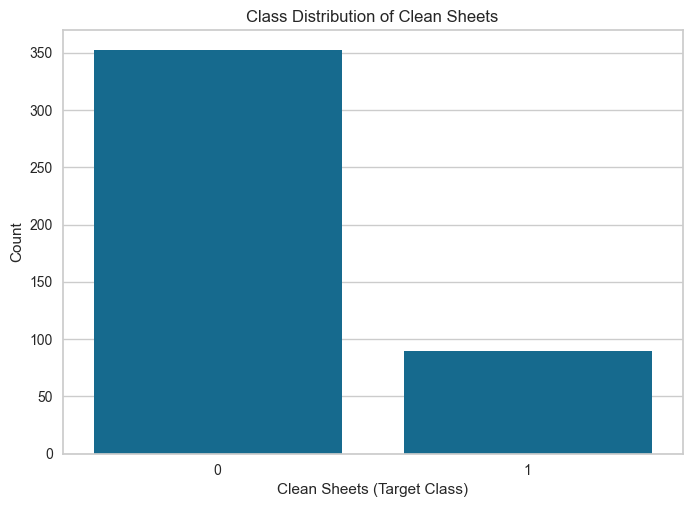

In [6]:
g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[cs_features]
g_cs_data_tar = g_cs_data_tar[cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [7]:
g_cs_base_model = setup(data=g_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        # remove_multicollinearity=True,
                        normalize=True,
                        feature_selection=True,
                        # polynomial_features=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 234, number of negative: 234
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4434
[LightGBM] [Info] Number of data points in the train set: 468, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(442, 73)"
4,Transformed data shape,"(601, 15)"
5,Transformed train set shape,"(468, 15)"
6,Transformed test set shape,"(133, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [8]:
best_base_g_cs = g_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.5731,0.5594,0.5452,0.2523,0.3346,0.0872,0.1068,0.5280
xgboost,Extreme Gradient Boosting,0.7218,0.5561,0.2571,0.3233,0.2709,0.1063,0.1147,0.5990
qda,Quadratic Discriminant Analysis,0.6214,0.5400,0.3143,0.2041,0.2446,0.0065,0.0086,0.4120
lightgbm,Light Gradient Boosting Machine,0.7054,0.5312,0.2357,0.2858,0.2514,0.0711,0.0754,0.7080
nb,Naive Bayes,0.5275,0.5274,0.4786,0.2110,0.2904,0.0123,0.0136,0.6770
knn,K Neighbors Classifier,0.5048,0.5224,0.5238,0.2094,0.2974,0.0128,0.0197,0.7140
dt,Decision Tree Classifier,0.6314,0.5165,0.3214,0.2340,0.2636,0.0338,0.0344,0.5880
rf,Random Forest Classifier,0.7249,0.5145,0.1571,0.2417,0.1849,0.0317,0.0341,0.6940
lr,Logistic Regression,0.5277,0.5071,0.4405,0.2061,0.2777,0.0004,-0.0041,4.0720
ridge,Ridge Classifier,0.5245,0.5071,0.4405,0.2031,0.2753,-0.0038,-0.0082,0.5270


In [9]:
evaluate_model(best_base_g_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [10]:
tune_model_gk_cs = tune_model(best_base_g_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6774,0.5133,0.5000,0.3000,0.3750,0.1755,0.1859
1,0.3871,0.4333,0.3333,0.1176,0.1739,-0.1572,-0.2117
2,0.4839,0.5200,0.5000,0.1875,0.2727,-0.0122,-0.0158
3,0.3871,0.3200,0.0000,0.0000,0.0000,-0.3603,-0.4163
4,0.5484,0.4867,0.3333,0.1667,0.2222,-0.0483,-0.0541
5,0.4839,0.5933,0.6667,0.2222,0.3333,0.0606,0.0854
6,0.6129,0.7560,0.5714,0.3077,0.4000,0.1507,0.1664
7,0.6129,0.6131,0.4286,0.2727,0.3333,0.0792,0.0832
8,0.4839,0.4643,0.2857,0.1538,0.2000,-0.1324,-0.1463


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [11]:
evaluate_model(tune_model_gk_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [12]:
final_best_base_g_cs = finalize_model(tune_model_gk_cs)
save_model(final_best_base_g_cs, './models/gk_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                 ('actual_estimator',
                  SGDClassifier(alpha=0.0001, average=False, cla

## DEF


clean_sheets
0    1637
1     379
Name: count, dtype: int64


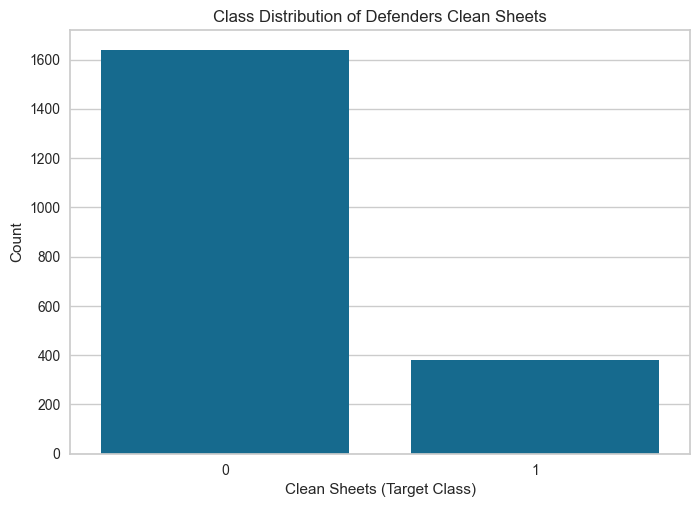

In [13]:
def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[cs_features]
def_cs_data_tar = def_cs_data_tar[cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Defenders Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [14]:
def_cs_base_model = setup(data=def_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1095, number of negative: 1095
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001948 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14110
[LightGBM] [Info] Number of data points in the train set: 2190, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(2016, 73)"
4,Transformed data shape,"(2795, 15)"
5,Transformed train set shape,"(2190, 15)"
6,Transformed test set shape,"(605, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [15]:
best_base_def_cs = def_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8079,0.7778,0.3017,0.5006,0.3665,0.2626,0.2790,1.1700
xgboost,Extreme Gradient Boosting,0.8164,0.7707,0.3283,0.5240,0.3994,0.2985,0.3119,0.9850
lightgbm,Light Gradient Boosting Machine,0.8101,0.7674,0.2788,0.4859,0.3470,0.2484,0.2638,1.2960
rf,Random Forest Classifier,0.8023,0.7558,0.2980,0.4590,0.3559,0.2474,0.2574,1.5140
gbc,Gradient Boosting Classifier,0.7874,0.7118,0.2524,0.4068,0.3026,0.1876,0.1984,1.5300
ada,Ada Boost Classifier,0.7264,0.6697,0.4182,0.3233,0.3613,0.1920,0.1965,1.4070
lda,Linear Discriminant Analysis,0.6222,0.6635,0.6305,0.2787,0.3858,0.1694,0.1989,0.9280
ridge,Ridge Classifier,0.6222,0.6633,0.6305,0.2787,0.3858,0.1694,0.1989,1.2530
lr,Logistic Regression,0.6208,0.6630,0.6266,0.2773,0.3836,0.1665,0.1953,1.3990
knn,K Neighbors Classifier,0.5861,0.6555,0.6670,0.2629,0.3767,0.1472,0.1838,2.4350


In [16]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [17]:
tune_model_def_cs = tune_model(best_base_def_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6127,0.6586,0.5556,0.2586,0.3529,0.1262,0.1450
1,0.6383,0.6849,0.6667,0.3000,0.4138,0.2034,0.2374
2,0.6596,0.7209,0.5926,0.3019,0.4000,0.1960,0.2177
3,0.7021,0.7079,0.5926,0.3404,0.4324,0.2500,0.2677
4,0.6738,0.6741,0.4444,0.2791,0.3429,0.1407,0.1474
5,0.7092,0.6983,0.5385,0.3256,0.4058,0.2285,0.2412
6,0.6667,0.6793,0.5000,0.2766,0.3562,0.1557,0.1681
7,0.5816,0.5783,0.3846,0.1887,0.2532,0.0076,0.0086
8,0.7163,0.7599,0.6538,0.3542,0.4595,0.2895,0.3145


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [18]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [19]:
final_best_base_def_cs = finalize_model(best_base_def_cs)
save_model(final_best_base_def_cs, './models/def_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

## MID


clean_sheets
0    1635
1     432
Name: count, dtype: int64


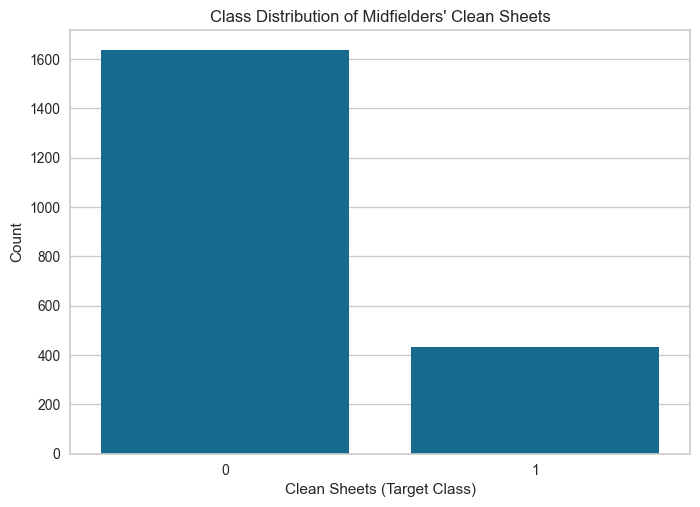

In [20]:
mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[cs_features]
mid_cs_data_tar = mid_cs_data_tar[cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Midfielders\' Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [21]:
mid_cs_base_model = setup(data=mid_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1095, number of negative: 1095
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.123938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14341
[LightGBM] [Info] Number of data points in the train set: 2190, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(2067, 73)"
4,Transformed data shape,"(2811, 15)"
5,Transformed train set shape,"(2190, 15)"
6,Transformed test set shape,"(621, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [22]:
best_base_mid_cs = mid_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7967,0.7277,0.2749,0.5315,0.3607,0.2541,0.2745,1.5510
et,Extra Trees Classifier,0.7718,0.7213,0.2813,0.4340,0.3397,0.2094,0.2175,1.2220
xgboost,Extreme Gradient Boosting,0.7849,0.7103,0.2751,0.4756,0.3465,0.2295,0.2425,1.4170
rf,Random Forest Classifier,0.7849,0.7099,0.2778,0.4812,0.3502,0.2323,0.2460,4.1010
gbc,Gradient Boosting Classifier,0.7669,0.6703,0.2276,0.4028,0.2864,0.1611,0.1723,1.8290
knn,K Neighbors Classifier,0.5553,0.6592,0.6753,0.2729,0.3885,0.1294,0.1620,1.3870
lda,Linear Discriminant Analysis,0.6065,0.6537,0.6023,0.2886,0.3898,0.1500,0.1724,1.0450
lr,Logistic Regression,0.6051,0.6533,0.6055,0.2879,0.3898,0.1494,0.1727,3.1260
ridge,Ridge Classifier,0.6030,0.6533,0.5956,0.2849,0.3850,0.1432,0.1647,6.2700
ada,Ada Boost Classifier,0.6908,0.6237,0.3303,0.2928,0.3074,0.1113,0.1124,1.7110


In [23]:
evaluate_model(best_base_mid_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [24]:
tune_model_mid_cs = tune_model(best_base_mid_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8069,0.7286,0.3226,0.5882,0.4167,0.3126,0.3328
1,0.7862,0.6930,0.1613,0.5000,0.2439,0.1559,0.1900
2,0.8276,0.7191,0.2667,0.7273,0.3902,0.3141,0.3681
3,0.7931,0.6797,0.2000,0.5000,0.2857,0.1899,0.2173
4,0.8000,0.7510,0.1333,0.5714,0.2162,0.1496,0.2027
5,0.7724,0.6330,0.2000,0.4000,0.2667,0.1493,0.1619
6,0.7847,0.6705,0.3333,0.4762,0.3922,0.2663,0.2725
7,0.7917,0.6237,0.1667,0.5000,0.2500,0.1628,0.1962
8,0.7847,0.6544,0.3333,0.4762,0.3922,0.2663,0.2725


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [25]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [26]:
final_best_base_mid_cs = finalize_model(best_base_mid_cs)
save_model(final_best_base_mid_cs, './models/mid_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                            

# Yellow Cards


In [27]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


yellow_cards
0    409
1     33
Name: count, dtype: int64


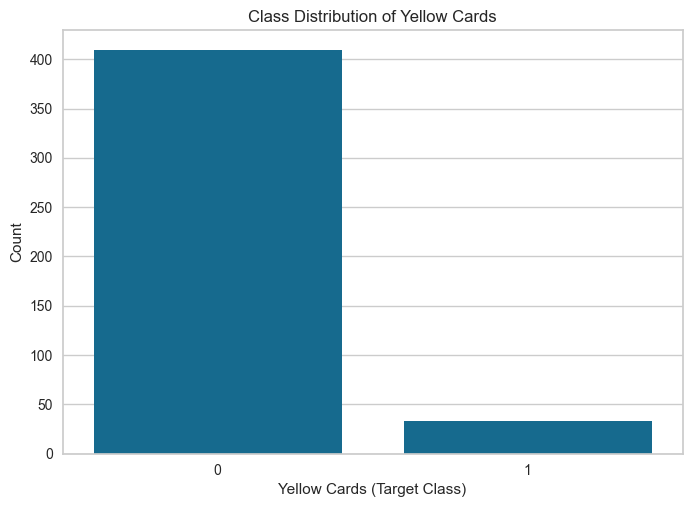

In [28]:
g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[y_features]
g_y_data_tar = g_y_data_tar[y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [29]:
g_y_base_model = setup(data=g_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 272, number of negative: 272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5854
[LightGBM] [Info] Number of data points in the train set: 544, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(442, 75)"
4,Transformed data shape,"(677, 15)"
5,Transformed train set shape,"(544, 15)"
6,Transformed test set shape,"(133, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [30]:
best_base_g_y = g_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9095,0.5657,0.1667,0.1667,0.1600,0.1249,0.1273,2.6660
dt,Decision Tree Classifier,0.8673,0.5614,0.2000,0.1250,0.1533,0.0843,0.0879,0.3810
lightgbm,Light Gradient Boosting Machine,0.9095,0.5439,0.1333,0.1500,0.1400,0.1065,0.1053,1.3100
et,Extra Trees Classifier,0.9159,0.5408,0.0833,0.2000,0.1167,0.0943,0.1067,3.1550
nb,Naive Bayes,0.7282,0.5374,0.2167,0.0752,0.1087,-0.0011,-0.0061,0.4270
rf,Random Forest Classifier,0.9159,0.5178,0.0833,0.1500,0.1067,0.0842,0.0889,0.6820
dummy,Dummy Classifier,0.9256,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.3960
gbc,Gradient Boosting Classifier,0.8998,0.4993,0.1000,0.1000,0.1000,0.0614,0.0599,1.3100
knn,K Neighbors Classifier,0.6281,0.4915,0.3833,0.0839,0.1365,0.0174,0.0195,0.3620
lda,Linear Discriminant Analysis,0.6604,0.4844,0.2667,0.0691,0.1061,-0.0141,-0.0225,2.3160


In [31]:
evaluate_model(best_base_g_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [32]:
tune_model_gk_y = tune_model(best_base_g_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9355,0.2241,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.8065,0.4138,0.0000,0.0000,0.0000,-0.0941,-0.1011
2,0.8065,0.8621,0.5000,0.1667,0.2500,0.1696,0.2037
3,0.9032,1.0000,1.0000,0.4000,0.5714,0.5279,0.5988
4,0.8387,0.4655,0.0000,0.0000,0.0000,-0.0839,-0.0860
5,0.9032,0.6207,0.5000,0.3333,0.4000,0.3497,0.3582
6,0.8387,0.2143,0.0000,0.0000,0.0000,-0.0839,-0.0860
7,0.9032,0.4881,0.3333,0.5000,0.4000,0.3497,0.3582
8,0.7742,0.4167,0.0000,0.0000,0.0000,-0.1244,-0.1260


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [33]:
final_best_base_g_y = finalize_model(best_base_g_y)
save_model(final_best_base_g_y, './models/gk_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                importance_type=None,
                                interaction_cons

## DEF


yellow_cards
0    1693
1     323
Name: count, dtype: int64


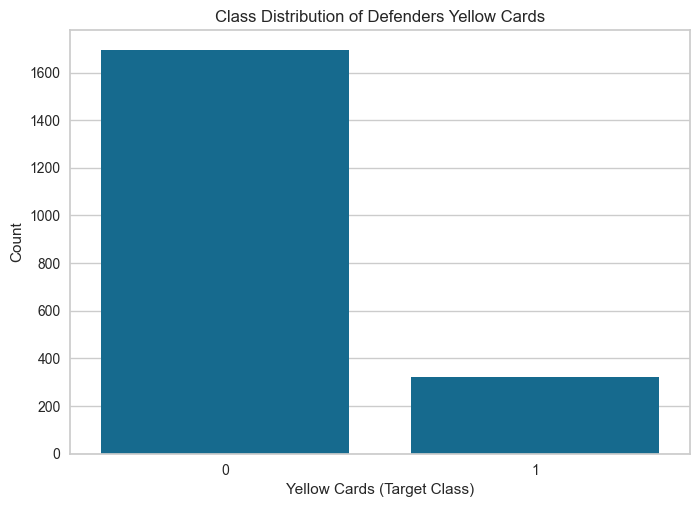

In [34]:
def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[y_features]
def_y_data_tar = def_y_data_tar[y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Defenders Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [35]:
def_y_base_model = setup(data=def_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1127, number of negative: 1127
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14683
[LightGBM] [Info] Number of data points in the train set: 2254, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(2016, 75)"
4,Transformed data shape,"(2859, 15)"
5,Transformed train set shape,"(2254, 15)"
6,Transformed test set shape,"(605, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [36]:
best_base_def_y = def_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.6825,0.5459,0.3055,0.1906,0.2326,0.0473,0.0498,1.0890
gbc,Gradient Boosting Classifier,0.7689,0.5408,0.1259,0.1561,0.1325,0.0106,0.0094,1.3690
lightgbm,Light Gradient Boosting Machine,0.7902,0.5401,0.1065,0.2041,0.1369,0.0331,0.0358,3.9880
et,Extra Trees Classifier,0.7682,0.5337,0.0749,0.1208,0.0913,-0.0302,-0.0324,1.6260
xgboost,Extreme Gradient Boosting,0.7767,0.5326,0.1150,0.1834,0.1395,0.0209,0.0216,5.8210
dt,Decision Tree Classifier,0.6825,0.5305,0.3065,0.1894,0.2324,0.0463,0.0498,0.9820
rf,Random Forest Classifier,0.7654,0.5295,0.1063,0.1378,0.1160,-0.0086,-0.0108,1.4600
nb,Naive Bayes,0.4614,0.5280,0.5666,0.1628,0.2527,0.0050,0.0053,0.9170
qda,Quadratic Discriminant Analysis,0.5025,0.5171,0.5184,0.1645,0.2494,0.0088,0.0130,1.1880
lr,Logistic Regression,0.5273,0.5113,0.4692,0.1609,0.2392,0.0023,0.0053,0.8830


In [37]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

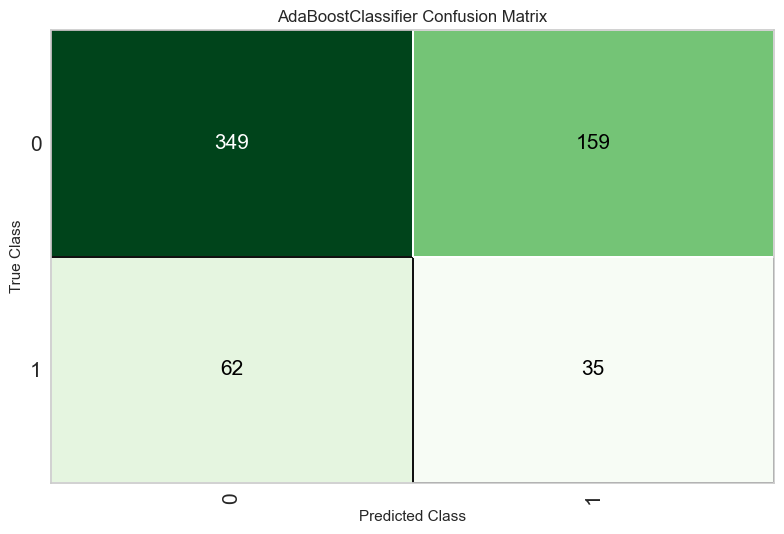

In [38]:
plot_model(best_base_def_y, plot='confusion_matrix')

### Tuned Model


In [39]:
tune_model_def_y = tune_model(best_base_def_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5493,0.5568,0.5652,0.1940,0.2889,0.0629,0.0822
1,0.6950,0.6280,0.3043,0.2059,0.2456,0.0633,0.0652
2,0.6596,0.4073,0.2174,0.1429,0.1724,-0.0305,-0.0315
3,0.6950,0.5604,0.3043,0.2059,0.2456,0.0633,0.0652
4,0.6170,0.5486,0.4783,0.2075,0.2895,0.0802,0.0933
5,0.6241,0.4342,0.1739,0.1053,0.1311,-0.0905,-0.0951
6,0.7092,0.6728,0.3182,0.2121,0.2545,0.0828,0.0854
7,0.6454,0.6545,0.5000,0.2200,0.3056,0.1134,0.1307
8,0.6950,0.4683,0.2273,0.1613,0.1887,0.0075,0.0077


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [40]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [41]:
final_best_base_def_y = finalize_model(best_base_def_y)
save_model(final_best_base_def_y, './models/def_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          num_leaves=3

## MID


yellow_cards
0    1712
1     355
Name: count, dtype: int64


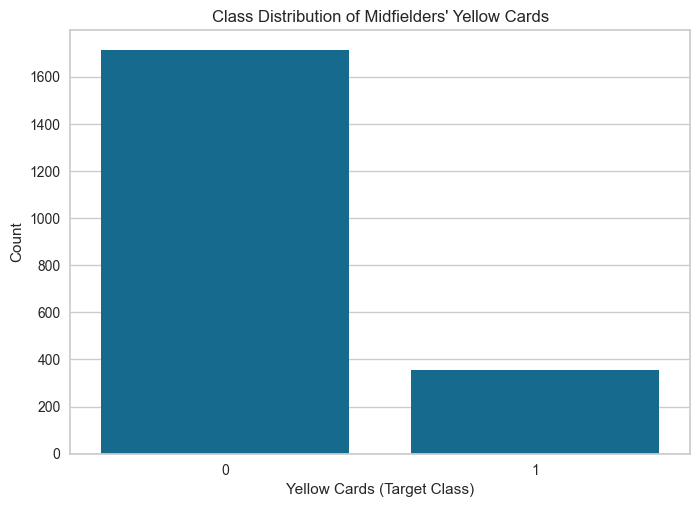

In [42]:
mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[y_features]
mid_y_data_tar = mid_y_data_tar[y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Midfielders\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [43]:
mid_y_base_model = setup(data=mid_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1138, number of negative: 1138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14883
[LightGBM] [Info] Number of data points in the train set: 2276, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(2067, 75)"
4,Transformed data shape,"(2897, 15)"
5,Transformed train set shape,"(2276, 15)"
6,Transformed test set shape,"(621, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [44]:
best_base_mid_y = mid_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5920,0.5934,0.5362,0.2186,0.3095,0.0881,0.1069,1.5760
ridge,Ridge Classifier,0.5920,0.5933,0.5362,0.2186,0.3095,0.0881,0.1069,1.0580
lr,Logistic Regression,0.5948,0.5927,0.5360,0.2202,0.3112,0.0908,0.1095,0.8790
rf,Random Forest Classifier,0.7987,0.5726,0.1250,0.3032,0.1718,0.0814,0.0933,1.4460
svm,SVM - Linear Kernel,0.5940,0.5712,0.4957,0.2051,0.2874,0.0659,0.0833,1.0870
nb,Naive Bayes,0.4330,0.5709,0.6798,0.1842,0.2893,0.0283,0.0494,1.0100
et,Extra Trees Classifier,0.7918,0.5686,0.1330,0.2691,0.1754,0.0753,0.0808,1.3820
qda,Quadratic Discriminant Analysis,0.5022,0.5636,0.5757,0.1883,0.2831,0.0343,0.0474,1.2410
ada,Ada Boost Classifier,0.7517,0.5556,0.1973,0.2249,0.2049,0.0630,0.0638,1.8870
knn,K Neighbors Classifier,0.5325,0.5544,0.5402,0.1934,0.2846,0.0425,0.0537,0.9830


In [45]:
evaluate_model(best_base_mid_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [46]:
tune_model_mid_y = tune_model(best_base_mid_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5517,0.5843,0.5600,0.2059,0.3011,0.0654,0.0833
1,0.5586,0.5927,0.5200,0.2000,0.2889,0.0531,0.0658
2,0.6000,0.5177,0.4000,0.1887,0.2564,0.0289,0.0327
3,0.5448,0.5470,0.5200,0.1940,0.2826,0.0420,0.0530
4,0.6483,0.6837,0.6000,0.2679,0.3704,0.1733,0.2004
5,0.5862,0.6557,0.6800,0.2464,0.3617,0.1454,0.1866
6,0.6736,0.5806,0.3750,0.2195,0.2769,0.0844,0.0895
7,0.5486,0.6108,0.6250,0.2113,0.3158,0.0888,0.1180
8,0.5069,0.5287,0.4800,0.1714,0.2526,-0.0043,-0.0056


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [47]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [48]:
final_best_base_mid_y = finalize_model(tune_model_mid_y)
save_model(final_best_base_mid_y, './models/mid_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## FWD


yellow_cards
0    434
1     61
Name: count, dtype: int64


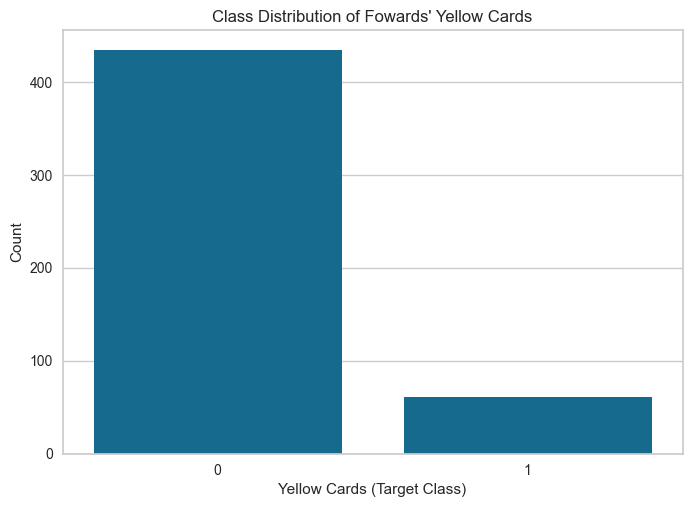

In [49]:
fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[y_features]
fwd_y_data_tar = fwd_y_data_tar[y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Fowards\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [50]:
fwd_y_base_model = setup(data=fwd_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 288, number of negative: 288
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8529
[LightGBM] [Info] Number of data points in the train set: 576, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(495, 75)"
4,Transformed data shape,"(725, 15)"
5,Transformed train set shape,"(576, 15)"
6,Transformed test set shape,"(149, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [51]:
best_base_fwd_y = fwd_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.8758,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3060
et,Extra Trees Classifier,0.8466,0.4951,0.0450,0.1250,0.0583,0.0087,0.0153,0.3990
dt,Decision Tree Classifier,0.7170,0.4934,0.1950,0.1161,0.1400,-0.0147,-0.0131,0.2990
xgboost,Extreme Gradient Boosting,0.7976,0.4833,0.0700,0.1500,0.0833,-0.0244,-0.0142,0.3240
nb,Naive Bayes,0.6045,0.4824,0.3350,0.1160,0.1709,-0.0134,-0.0148,0.2810
rf,Random Forest Classifier,0.8264,0.4768,0.1150,0.2233,0.1349,0.0541,0.0669,0.4280
gbc,Gradient Boosting Classifier,0.7950,0.4756,0.1150,0.1133,0.1117,-0.0008,-0.0013,0.4410
lr,Logistic Regression,0.5834,0.4744,0.3800,0.1190,0.1793,-0.0078,-0.0062,0.3100
ridge,Ridge Classifier,0.5806,0.4729,0.3800,0.1179,0.1780,-0.0097,-0.0084,0.2760
svm,SVM - Linear Kernel,0.5034,0.4725,0.4550,0.1206,0.1868,-0.0085,-0.0247,0.2830


In [52]:
evaluate_model(best_base_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [53]:
tune_model_fwd_y = tune_model(best_base_fwd_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4571,0.5167,0.6000,0.1500,0.2400,0.0148,0.0236
1,0.4571,0.5167,0.6000,0.1500,0.2400,0.0148,0.0236
2,0.5143,0.6333,0.8000,0.2000,0.3200,0.1185,0.1886
3,0.5429,0.7419,1.0000,0.2000,0.3333,0.1765,0.3111
4,0.4286,0.4597,0.5000,0.1000,0.1667,-0.0294,-0.0518
5,0.4286,0.4597,0.5000,0.1000,0.1667,-0.0294,-0.0518
6,0.4412,0.4667,0.5000,0.1053,0.1739,-0.0254,-0.0433
7,0.4412,0.4667,0.5000,0.1053,0.1739,-0.0254,-0.0433
8,0.5000,0.6083,0.7500,0.1579,0.2609,0.0825,0.1406


Fitting 10 folds for each of 4 candidates, totalling 40 fits


In [54]:
evaluate_model(tune_model_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [55]:
final_best_base_fwd_y = finalize_model(tune_model_fwd_y)
save_model(final_best_base_fwd_y, './models/fwd_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          n_estimators